<a href="https://colab.research.google.com/github/nishantkapps/aiml-projects/blob/main/SIG742Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<hr><font face='Tahoma' size=4>
Student ID : 224918243 <br>
Student Name : Nishant Killedar <br>
Attempted High Distinction Question : Yes <br>
<hr>
Course : SIG 742 Modern Data Science <br>
Batch : MASTER OF DATA SCIENCE (GLOBAL) - JUN'24 A <br>
End Term Assessment<br>
</font><hr>

# Part - 1

In [142]:
# Importing some basic libraries, although the questions do not require use of these (except math)
# Have used these libraries to provide additional information for the answers
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.simplefilter('once')

In [3]:
data = pd.read_csv('/content/data/transactionrecord.csv')

In [4]:
data.head()

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom


<hr>

## Answer 1.1
<hr>

In [5]:
# Using PySpark to do some of the data wrangling process, so that:
#  1.1.1 For the ’NA’ in CustomerNo columns, change it to ’-1’.
#  1.1.2 Process the text in productName column, only alphabet characters left, and save the processed
#        result to a new column productName_process and show the first 5 rows

In [7]:
!pip install pyspark
!pip install findspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.3-py2.py3-none-any.whl size=317840625 sha256=2bfa87fcaee3c14b626de967e714667b93b6de502b3cb3954e3c883404a9da60
  Stored in directory: /root/.cache/pip/wheels/1b/3a/92/28b93e2fbfdbb07509ca4d6f50c5e407f48dce4ddbda69a4ab
Successfully built pyspark


In [8]:
import findspark
findspark.init()

In [9]:
from pyspark.sql import SparkSession

In [10]:
spark = SparkSession \
    .builder \
    .appName("SIG742Task2") \
    .getOrCreate()

In [13]:
path = '/content/data/transactionrecord.csv'

In [14]:
sdf = spark.read.option("header","true").csv(path)
sdf.show(5)

+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+
|TransactionNo|     Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|
+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+
|       581482|12/9/2019|    22485|Set Of 2 Wooden M...|             0ca|21.47|      12|     17490|United Kingdom|
|       581475|12/9/2019|    22596|Christmas Star Wi...|             0ca|10.65|      36|     13069|United Kingdom|
|       581475|12/9/2019|    23235|Storage Tin Vinta...|             0ca|11.53|      12|     13069|United Kingdom|
|       581475|12/9/2019|    23272|Tree T-Light Hold...|             0ca|10.65|      12|     13069|United Kingdom|
|       581475|12/9/2019|    23239|Set Of 4 Knick Kn...|             0ca|11.94|       6|     13069|United Kingdom|
+-------------+---------+---------+--------------------+----------------+-----+-

####  1.1.1 For the ’NA’ in CustomerNo columns, change it to ’-1’.

In [15]:
sdf.filter(sdf['CustomerNo'] == -1).count()

55

In [16]:
from pyspark.sql.functions import when
df3 = sdf.withColumn("CustomerNo", when(sdf.CustomerNo == -1,'NA') \
      .otherwise(sdf.CustomerNo))

In [18]:
df3.filter(df3['CustomerNo']=='NA').count()

55

In [19]:
df3.filter(df3['CustomerNo']=='NA').show(5)

+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|TransactionNo|      Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|
+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|      C581406| 12/8/2019|   46000M|Polyester Filler ...|             0ca| 6.19|    -240|        NA|United Kingdom|
|      C581406| 12/8/2019|   46000S|Polyester Filler ...|             0ca| 6.19|    -300|        NA|United Kingdom|
|      C575153| 11/8/2019|    22947|Wooden Advent Cal...|             0ca|44.25|      -1|        NA|United Kingdom|
|      C574288| 11/3/2019|    22178|Victorian Glass H...|             0ca|25.37|      -1|        NA|United Kingdom|
|      C573180|10/28/2019|    23048|Set Of 10 Lantern...|             0ca| 14.5|      -1|        NA|United Kingdom|
+-------------+----------+---------+--------------------+---------------

In [20]:
df4 = df3.withColumn("CustomerNo", when(df3.CustomerNo == 'NA',-1) \
      .otherwise(df3.CustomerNo))

In [21]:
df4.filter(df4['CustomerNo']==-1).count()

55

In [22]:
df4.filter(df4['CustomerNo']==-1).show(5)

+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|TransactionNo|      Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|
+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|      C581406| 12/8/2019|   46000M|Polyester Filler ...|             0ca| 6.19|    -240|        -1|United Kingdom|
|      C581406| 12/8/2019|   46000S|Polyester Filler ...|             0ca| 6.19|    -300|        -1|United Kingdom|
|      C575153| 11/8/2019|    22947|Wooden Advent Cal...|             0ca|44.25|      -1|        -1|United Kingdom|
|      C574288| 11/3/2019|    22178|Victorian Glass H...|             0ca|25.37|      -1|        -1|United Kingdom|
|      C573180|10/28/2019|    23048|Set Of 10 Lantern...|             0ca| 14.5|      -1|        -1|United Kingdom|
+-------------+----------+---------+--------------------+---------------

####  1.1.2 Process the text in productName column, only alphabet characters left, and save the processed result to a new column productName_process and show the first 5 rows

In [23]:
from pyspark.sql.functions import *

In [24]:
df_new = sdf.withColumn('ProductName_process', regexp_replace('ProductName', '[0-9]', ''))

In [25]:
df_new[['ProductName', 'ProductName_process']].show(5)

+--------------------+--------------------+
|         ProductName| ProductName_process|
+--------------------+--------------------+
|Set Of 2 Wooden M...|Set Of  Wooden Ma...|
|Christmas Star Wi...|Christmas Star Wi...|
|Storage Tin Vinta...|Storage Tin Vinta...|
|Tree T-Light Hold...|Tree T-Light Hold...|
|Set Of 4 Knick Kn...|Set Of  Knick Kna...|
+--------------------+--------------------+
only showing top 5 rows



<hr>

## Answer 1.2
<hr>

Find out the revenue on each transaction date. In order to achieve the above, some wrangling work is
required to be done:

#### 1.2.1
Using pyspark to calculate the revenue (price * Quantity) and save as float format in pyspark dataframe to show the top 5 rows.
<hr>

In [26]:
sdf = sdf.withColumn("Revenue", sdf['Price']*sdf['Quantity'])

In [27]:
sdf.show(5)

+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+------------------+
|TransactionNo|     Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|           Revenue|
+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+------------------+
|       581482|12/9/2019|    22485|Set Of 2 Wooden M...|             0ca|21.47|      12|     17490|United Kingdom|            257.64|
|       581475|12/9/2019|    22596|Christmas Star Wi...|             0ca|10.65|      36|     13069|United Kingdom|383.40000000000003|
|       581475|12/9/2019|    23235|Storage Tin Vinta...|             0ca|11.53|      12|     13069|United Kingdom|138.35999999999999|
|       581475|12/9/2019|    23272|Tree T-Light Hold...|             0ca|10.65|      12|     13069|United Kingdom|127.80000000000001|
|       581475|12/9/2019|    23239|Set Of 4 Knick Kn...|      

<hr>

#### 1.2.2
Transform the pyspark dataframe to pandas dataframe (named as df) and create the column transaction_date with date format according to Date. Print your df pandas dataframe with top 5 rows after creating the column transaction_date.
<hr>

In [28]:
df = sdf.toPandas()

In [29]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,Revenue
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,257.64
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,383.40
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,138.36
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,127.80
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,71.64


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   TransactionNo     536350 non-null  object 
 1   Date              536350 non-null  object 
 2   ProductNo         536350 non-null  object 
 3   ProductName       536350 non-null  object 
 4   Product_category  536350 non-null  object 
 5   Price             536350 non-null  object 
 6   Quantity          536350 non-null  object 
 7   CustomerNo        536350 non-null  object 
 8   Country           536350 non-null  object 
 9   Revenue           536350 non-null  float64
dtypes: float64(1), object(9)
memory usage: 40.9+ MB


In [31]:
df['transaction_date'] = pd.to_datetime(df['Date'])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   TransactionNo     536350 non-null  object        
 1   Date              536350 non-null  object        
 2   ProductNo         536350 non-null  object        
 3   ProductName       536350 non-null  object        
 4   Product_category  536350 non-null  object        
 5   Price             536350 non-null  object        
 6   Quantity          536350 non-null  object        
 7   CustomerNo        536350 non-null  object        
 8   Country           536350 non-null  object        
 9   Revenue           536350 non-null  float64       
 10  transaction_date  536350 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 45.0+ MB


In [33]:
date_rev_df = df.groupby('transaction_date').Revenue.agg('sum').reset_index()

In [34]:
date_rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  305 non-null    datetime64[ns]
 1   Revenue           305 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.9 KB


In [35]:
date_rev_df['transaction_date']

,transaction_date
0,2018-12-01
1,2018-12-02
2,2018-12-03
3,2018-12-05
4,2018-12-06
...,...
300,2019-12-05
301,2019-12-06
302,2019-12-07
303,2019-12-08


<hr>

#### 1.2.3
Plot the sum of revenue on transaction_date in a line plot and find out any immediate pattern / insight?
<hr>

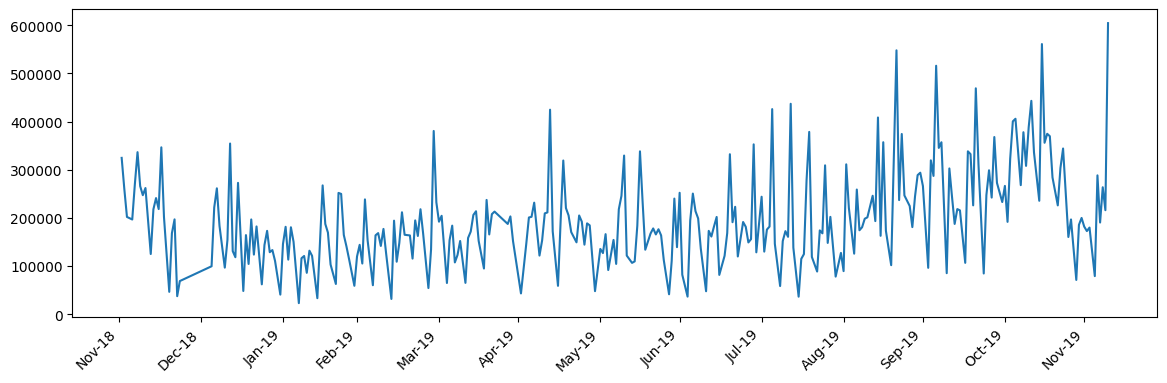

In [36]:
plt.figure(figsize=(14,4))
plt.plot(date_rev_df['transaction_date'], date_rev_df['Revenue'])
plt.xticks(date_rev_df['transaction_date'])

import matplotlib.dates as mdates ## Import required library
months = mdates.MonthLocator(interval=1, bymonthday=-1)  ## 1 month apart & show last date
plt.gca().xaxis.set_major_locator(months) ## Set months as major locator
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%y')) ##Display format - update here to change
plt.xticks(rotation=45, ha='right') ##Adjust angle and horizontal align right
plt.show()

As can be seen from the plot above,
<li> We can see spikes of revenue in certain weeks, more analysis is needed by week to understand trends
<li> The revenue is increasing gradually, we can see more spikes of high revenue in Aug, Sep, Oct
<li> November sees a slight dip and there could be some seasonality due to holidays

In [37]:
from datetime import datetime
date1 = np.datetime64(datetime.strptime('04-01-2019', '%m-%d-%Y').date())
date2 = np.datetime64(datetime.strptime('05-01-2019', '%m-%d-%Y').date())
print(date1, date2)  # printed in default format

2019-04-01 2019-05-01


In [38]:
date_rev_df_sample = date_rev_df[date_rev_df['transaction_date'].between(date1,date2)]

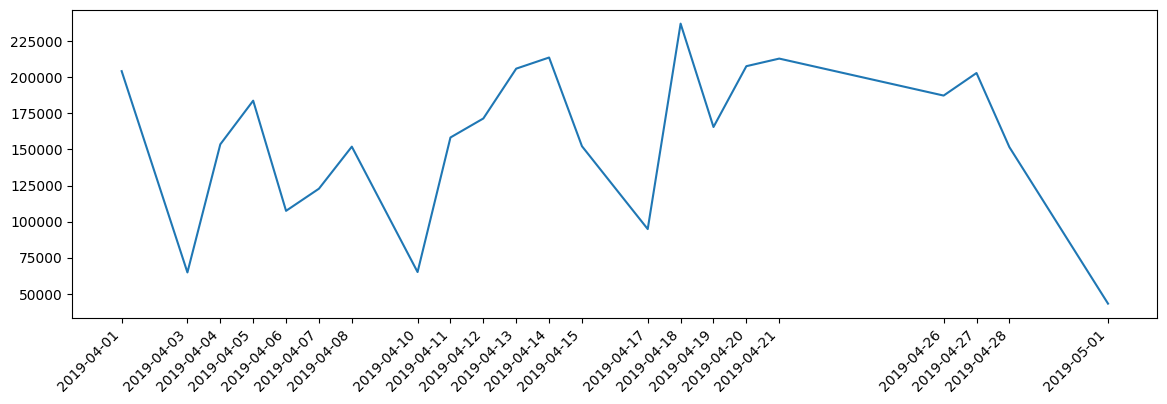

In [39]:
plt.figure(figsize=(14,4))
plt.plot(date_rev_df_sample['transaction_date'], date_rev_df_sample['Revenue'])
plt.xticks(date_rev_df_sample['transaction_date'])
plt.xticks(rotation=45, ha='right')
plt.show()

Looking at the data for one month, we can also see the following
<li> Some days do not have any revenue ( could be related to no sales or also could indicate missing data)
<li> There is no revenue on Tuesdays ( 2nd / 9th / 16th / 23rd / 30th ) - indicates a weekly off on Tuesday
<li> There is no revenue on 22, 23, 24, 25 April - indicates a longer holiday

In [40]:
date3 = np.datetime64(datetime.strptime('04-01-2019', '%m-%d-%Y').date())
date4 = np.datetime64(datetime.strptime('04-07-2019', '%m-%d-%Y').date())
print(date3, date4)  # printed in default format

2019-04-01 2019-04-07


In [41]:
date_rev_df_sample2 = date_rev_df[date_rev_df['transaction_date'].between(date3,date4)]

In [42]:
date5 = np.datetime64(datetime.strptime('04-08-2019', '%m-%d-%Y').date())
date6 = np.datetime64(datetime.strptime('04-14-2019', '%m-%d-%Y').date())
print(date5, date6)  # printed in default format

2019-04-08 2019-04-14


In [43]:
date_rev_df_sample3 = date_rev_df[date_rev_df['transaction_date'].between(date5,date6)]

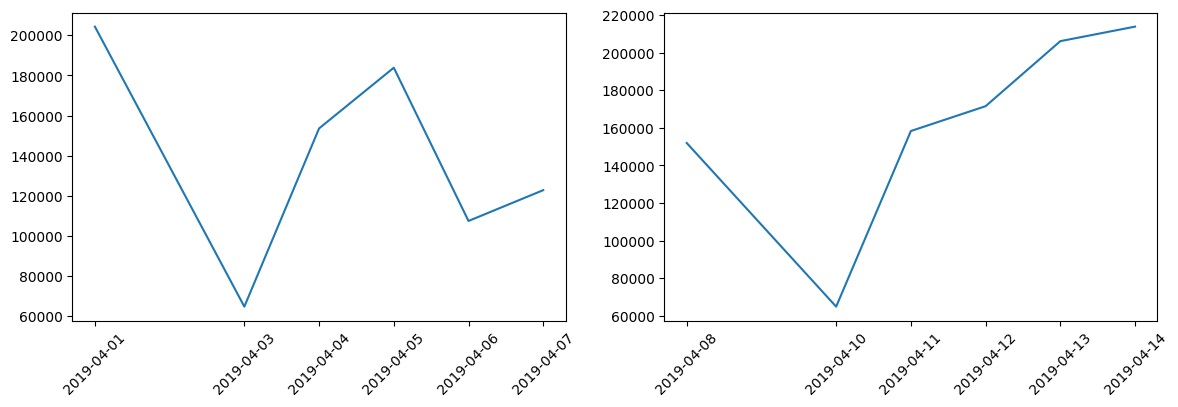

In [44]:
fig,ax=plt.subplots(1,2, figsize=(14,4))
ax[0].plot(date_rev_df_sample2['transaction_date'], date_rev_df_sample2['Revenue'])
ax[0].set_xticks(date_rev_df_sample2['transaction_date'])
ax[0].xaxis.set_tick_params(rotation=45)
ax[1].plot(date_rev_df_sample3['transaction_date'], date_rev_df_sample3['Revenue'])
ax[1].set_xticks(date_rev_df_sample3['transaction_date'])
ax[1].xaxis.set_tick_params(rotation=45)
plt.show()

Drilling down further into a week
<li> No revenue on Tuesday
<li> Wednesday generally has lowest revenue of the week (excluding Tuesday)
<li> Revenue increases from Thursday thru Mon and drops (more analysis needed by day for insights)

<hr>

## Answer 1.3
<hr>

#### 1.3.1 Determine which workday (day of the week), generates the most sales (plotting the results in a line chart with workday on averaged revenues).

In [45]:
df['day_of_week'] = df['transaction_date'].dt.day_name()

In [46]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,Revenue,transaction_date,day_of_week
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,257.64,2019-12-09,Monday
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,383.40,2019-12-09,Monday
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,138.36,2019-12-09,Monday
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,127.80,2019-12-09,Monday
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,71.64,2019-12-09,Monday


In [47]:
rev_dow = df.groupby('day_of_week').Revenue.agg('mean').reset_index()

In [48]:
rev_dow

,day_of_week,Revenue
0,Friday,115.479760
1,Monday,119.241638
2,Saturday,117.389493
3,Sunday,127.947587
4,Thursday,101.541531
5,Wednesday,82.594631


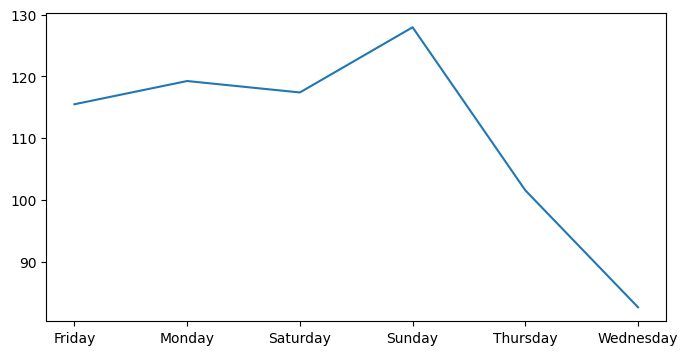

In [49]:
plt.figure(figsize=(8,4))
plt.plot(rev_dow['day_of_week'], rev_dow['Revenue'])
plt.show()

### Sunday has the highest average revenue and as mentioned earlier, there is no revenue on Tuesdays

#### 1.3.2 Identify the name of product (column productName_process) that contributes the highest revenue  on ‘that workday’ (you need to find out from 1.3.1) and the name of product (column productName_process) that has the highest sales volume (sum of the Quantity), no need to remove negative quantity transactions.) on ‘that workday’ (you need to find out from 1.3.1).

In [50]:
# Convert all numeric columns to numeric type (int or float)
df['Quantity']=df['Quantity'].apply(pd.to_numeric, errors='coerce')
df['Price']=df['Price'].apply(pd.to_numeric, errors='coerce')
df['CustomerNo']=df['CustomerNo'].apply(pd.to_numeric, errors='coerce')
df['ProductNo']=df['ProductNo'].apply(pd.to_numeric, errors='coerce')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   TransactionNo     536350 non-null  object        
 1   Date              536350 non-null  object        
 2   ProductNo         485429 non-null  float64       
 3   ProductName       536350 non-null  object        
 4   Product_category  536350 non-null  object        
 5   Price             536350 non-null  float64       
 6   Quantity          536350 non-null  int64         
 7   CustomerNo        536350 non-null  int64         
 8   Country           536350 non-null  object        
 9   Revenue           536350 non-null  float64       
 10  transaction_date  536350 non-null  datetime64[ns]
 11  day_of_week       536350 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 49.1+ MB


<hr>

#### Use groupby and aggregation functions to get the revenue and sales volume for each product on Sunday. The goal is to find the product with maximum revenue and sales volume on Sunday (which is the day of maximum average sales). After grouping and aggregation, we use np.max to get the max value for both sales / revenue and find the product that has these values
<hr>

In [52]:
revprod = df[df['day_of_week']=='Sunday'].groupby('ProductName').Revenue.agg('sum').reset_index()
salprod = df[df['day_of_week']=='Sunday'].groupby('ProductName').Quantity.agg('sum').reset_index()

In [53]:
salprod[salprod['Quantity']==np.max(salprod['Quantity'])]

,ProductName,Quantity
3344,World War 2 Gliders Asstd Designs,18051


In [54]:
revprod[revprod['Revenue']==np.max(revprod['Revenue'])]

,ProductName,Revenue
3344,World War 2 Gliders Asstd Designs,187081.35


<hr>
<li> Product with the highest sales volume on <u>Sunday</u> is <b>World War 2 Gliders Asstd Designs</b>
<li> Product with the highest revenue on <u>Sunday</u> is <b>World War 2 Gliders Asstd Designs</b>
<hr>

#### 1.3.3 Please provide two plots showing the top 5 products that contribute the highest revenues in general and top 5 products that have the highest sales volumes in general.

In [55]:
top5rev=df.groupby('ProductName').Revenue.agg('sum').reset_index().sort_values(by=['Revenue'], ascending=False).head(5)
top5sal=df.groupby('ProductName').Quantity.agg('sum').reset_index().sort_values(by=['Quantity'], ascending=False).head(5)

#### Use group by product, aggregation function sum for Revenue/Quantity features and then sort in descending order to get the top 5 products contributing highest revenues / sales volume.

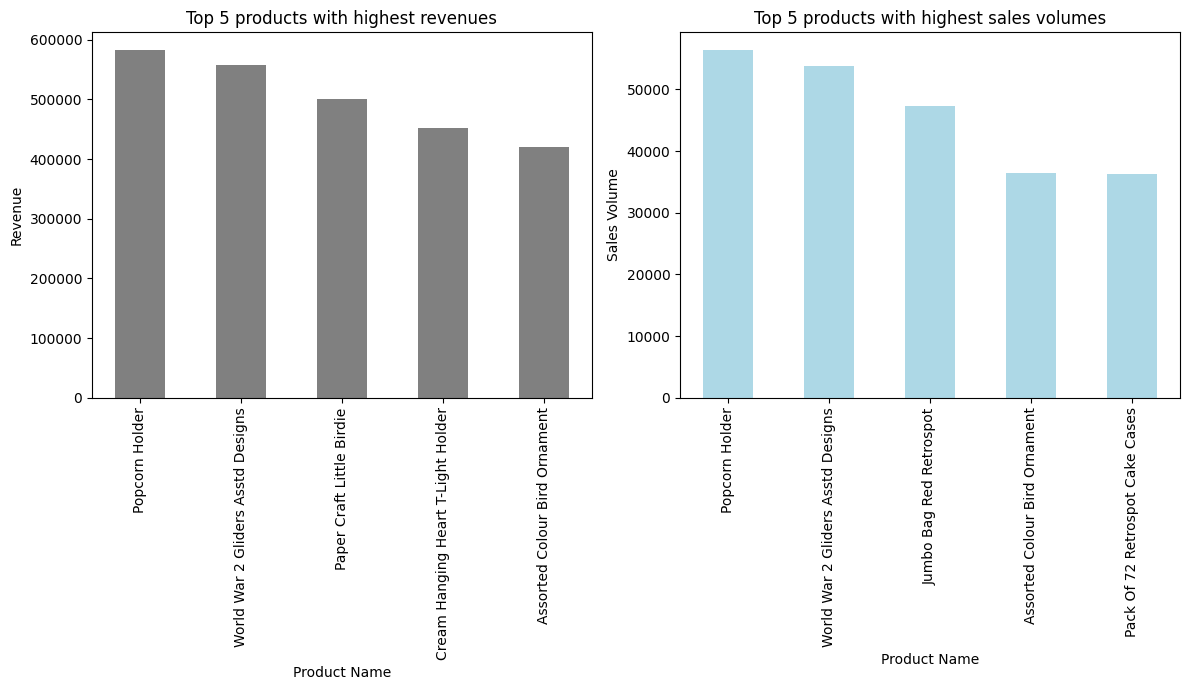

In [56]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].bar(top5rev['ProductName'], top5rev['Revenue'],width=0.5, color='gray')
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_title('Top 5 products with highest revenues')
ax[0].set_xlabel('Product Name')
ax[0].set_ylabel('Revenue')
#ax[0].set_xticklabels(top5rev['ProductName'], rotation=90)
ax[1].bar(top5sal['ProductName'], top5sal['Quantity'],width=0.5, color='lightblue')
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_title('Top 5 products with highest sales volumes')
ax[1].set_xlabel('Product Name')
ax[1].set_ylabel('Sales Volume')
#ax[1].set_xticklabels(top5sal['ProductName'], rotation=90)
plt.tight_layout()
plt.show();

<hr>

## Answer 1.4
<hr>

#### Which country generates the highest revenue? Additionally, identify the month in that country that has the highest revenue.

In [57]:
df['month'] = df['transaction_date'].dt.month

In [58]:
print('The country that generates highest revenue is')
df.groupby('Country').Revenue.agg('sum').sort_values(ascending=False).head(1)

The country that generates highest revenue is


,Revenue
Country,
United Kingdom,49994030.17


In [59]:
print('The month in which UK generates the highest revenue is')
df[df['Country']=='United Kingdom'].groupby('month').Revenue.agg('sum').sort_values(ascending=False).head(1)

The month in which UK generates the highest revenue is


,Revenue
month,
11,6737639.97


<hr>

## Answer 1.5
<hr>

#### Let’s do some analysis on the CustomerNo and their transactions. Determine the shopping frequency of customers to identify who shops most frequently (find out the highest distinct count of transactionNo on customer level, be careful with those transactions that is not for shopping – filter those transaction quantity <= 0). Also, find out what products (column productName_process) ‘this customer’ typically buys based on the Quantity of products purchased.

In [60]:
df[df['Quantity']<=0].groupby('CustomerNo').TransactionNo.agg('nunique').sort_values(ascending=False).head(1)

,TransactionNo
CustomerNo,
17841,45


In [61]:
df[df['CustomerNo']==17841].groupby('ProductName').Quantity.agg('sum').sort_values(ascending=False).head(10)

,Quantity
ProductName,
Disco Ball Christmas Decoration,1776
Chilli Lights,587
Heart Decoration Rustic Hanging,384
Gumball Coat Rack,269
Assorted Colour Lizard Suction Hook,265
Set Of 3 Wooden Heart Decorations,239
Gingham Heart Decoration,232
Skulls And Crossbones Wrap,225
Popart Wooden Pencils Asst,200


In [62]:
df.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Product_category',
       'Price', 'Quantity', 'CustomerNo', 'Country', 'Revenue',
       'transaction_date', 'day_of_week', 'month'],
      dtype='object')

<hr>

## Answer 1.6
<hr>

#### As the data scientist, you would like to build a basket-level analysis on the product customer buying (filter the ‘df’ dataframe with df[’Quantity’]>0). In this task, you need to: <br>

<li> 1.6.1 Group by the transactionNo and aggregate the category of product (column product_category) into list on transactionNo level. Similarly, group and aggregate name of product (column productName_process) into list on transactionNo level.

<li> 1.6.2 Removing duplicates on adjacent elements in the list from product_category you obtained from 1.6.1, such as [product category 1, product category 1, product category 2, ...] will be processed as [product category 1, product category 2,....]. After this processing, there will be no duplicates on on adjacent elements in the list. Please save your processed dataframe as ‘df_1’ and print the top 10 rows.

In [63]:
df_1 = df[df['Quantity']>0].groupby('TransactionNo').aggregate({'Product_category':list, 'ProductName':list}).reset_index()

In [64]:
df_1

,TransactionNo,Product_category,ProductName
0,536365,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca]","[Cream Hanging Heart T-Light Holder, White Mor..."
1,536366,"[0ca, 0ca]","[Hand Warmer Union Jack, Hand Warmer Red Retro..."
2,536367,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, ...","[Assorted Colour Bird Ornament, Poppy's Playho..."
3,536368,"[0ca, 0ca, 0ca, 0ca]","[Jam Making Set With Jars, Red Coat Rack Paris..."
4,536369,[0ca],[Bath Building Block Word]
...,...,...,...
19785,581583,"[0ca, 0ca]","[6 Chocolate Love Heart T-Lights, Lunch Bag Re..."
19786,581584,"[0ca, 0ca]","[Red Flock Love Heart Photo Frame, 6 Chocolate..."
19787,581585,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, ...","[Black Tea Towel Classic Design, Assorted Bott..."
19788,581586,"[0ca, 0ca, 0ca, 0ca]","[Large Cake Stand Hanging Strawbery, Set Of 3 ..."


In [65]:
def remove_adjacent(nums):
  a = nums[:1]
  for item in nums[1:]:
    if item != a[-1]:
      a.append(item)
  return a

In [66]:
nums = df_1.loc[0,:]['Product_category']
adjnums = remove_adjacent(nums)
print(adjnums)

['0ca']


In [67]:
df_1['Product_category']=df_1['Product_category'].apply(lambda x: list(remove_adjacent(x)))
df_1['ProductName']=df_1['ProductName'].apply(lambda x: list(remove_adjacent(x)))

In [68]:
df_1.head(10)

,TransactionNo,Product_category,ProductName
0,536365,[0ca],"[Cream Hanging Heart T-Light Holder, White Mor..."
1,536366,[0ca],"[Hand Warmer Union Jack, Hand Warmer Red Retro..."
2,536367,[0ca],"[Assorted Colour Bird Ornament, Poppy's Playho..."
3,536368,[0ca],"[Jam Making Set With Jars, Red Coat Rack Paris..."
4,536369,[0ca],[Bath Building Block Word]
5,536370,[0ca],"[Alarm Clock Bakelike Pink, Alarm Clock Bakeli..."
6,536371,[0ca],[Paper Chain Kit 50'S Christmas]
7,536372,[0ca],"[Hand Warmer Red Retrospot, Hand Warmer Union ..."
8,536373,[0ca],"[Cream Hanging Heart T-Light Holder, White Mor..."
9,536374,[0ca],[Victorian Sewing Box Large]


<hr>

## Answer 1.7
<hr>

#### Continue work on the results of question 1.6, now for each of the transaction, you will have a list of product categories. To further conduct the analysis, you need to finish below by using dataframe ‘df_1’: <br>
<ul>
<li> 1.7.1 Create new column prod_len to find out the length of the list from product_category on each transaction. Print the first five rows of dataframe ‘df_1’. <br><br>
<li> 1.7.2 Transform the list in product_category from [productcategory1, productcategory2...] to ‘start > productcategory1 > productcategory2 > ... > conversion’ with new column path. You need to add ‘start’ as the first element, and ‘conversion’ as the last. Also you need to use ‘ > ’ to connect each of the transition on products (there is a space between the elements and the transition symbol >). The final format after the transition is given in example as below fig. 2. Define the function data_processing to achieve above with three arguments: df which is the dataframe name, maxlength with default value of 3 for filtering the dataframe with prod_len" <=maxlength and minlength with default value of 1 for filtering the dataframe with prod_len >=minlength. The function data_processing will return the new dataframe ‘df_2’. Run your defined function with dataframe ‘df_1’, maxlength = 5 and minlength = 2, print the dataframe ‘df_2’ with top 10 rows.
</ul>

In [69]:
df_1['prod_len']=df_1['Product_category'].apply(len)

In [70]:
df_1.head(5)

,TransactionNo,Product_category,ProductName,prod_len
0,536365,[0ca],"[Cream Hanging Heart T-Light Holder, White Mor...",1
1,536366,[0ca],"[Hand Warmer Union Jack, Hand Warmer Red Retro...",1
2,536367,[0ca],"[Assorted Colour Bird Ornament, Poppy's Playho...",1
3,536368,[0ca],"[Jam Making Set With Jars, Red Coat Rack Paris...",1
4,536369,[0ca],[Bath Building Block Word],1


In [71]:
pd.options.mode.chained_assignment = None

In [72]:
def iterate_list(list1):
    str1 = 'start > '
    for str2 in list1 :
        str1+=str2+' > '
    str1+='conversion'
    return str1

In [73]:
def data_processing(df, maxlength=3, minlength=1):
    df_2 = df[(df['prod_len']>=minlength) & (df['prod_len']<=maxlength)]
    df_2['prod_cat_str'] = df_2['Product_category'].apply(lambda x:iterate_list(x))
    return df_2

In [74]:
df_2 = data_processing(df_1, 5, 2)

In [75]:
df_2.head(10)

,TransactionNo,Product_category,ProductName,prod_len,prod_cat_str
13,536378,"[0ca, 1ca, 0ca]","[Strawberry Charlotte Bag, Childrens Cutlery R...",3,start > 0ca > 1ca > 0ca > conversion
27,536395,"[0ca, 1ca, 0ca]","[Black Heart Card Holder, Assorted Colour Bird...",3,start > 0ca > 1ca > 0ca > conversion
36,536404,"[0ca, 1ca, 0ca, 4ca, 0ca]","[Heart Ivory Trellis Small, Clear Drawer Knob ...",5,start > 0ca > 1ca > 0ca > 4ca > 0ca > conversion
40,536408,"[0ca, 1ca, 0ca]","[Magic Drawing Slate Dinosaur, Magic Drawing S...",3,start > 0ca > 1ca > 0ca > conversion
42,536412,"[0ca, 4ca, 0ca]","[Round Snack Boxes Set Of4 Woodland, Round Sna...",3,start > 0ca > 4ca > 0ca > conversion
43,536415,"[0ca, 1ca, 0ca]","[60 Cake Cases Vintage Christmas, Paper Chain ...",3,start > 0ca > 1ca > 0ca > conversion
52,536464,"[0ca, 1ca, 0ca]","[Black Sweetheart Bracelet, Diamante Hair Grip...",3,start > 0ca > 1ca > 0ca > conversion
72,536532,"[0ca, 1ca, 0ca]","[Box Of 24 Cocktail Parasols, Grow Your Own Pl...",3,start > 0ca > 1ca > 0ca > conversion
82,536542,"[0ca, 4ca]","[Recycling Bag Retrospot, Jumbo Storage Bag Sk...",2,start > 0ca > 4ca > conversion
83,536544,"[0ca, 1ca, 0ca, 4ca, 0ca]","[Decorative Rose Bathroom Bottle, Decorative C...",5,start > 0ca > 1ca > 0ca > 4ca > 0ca > conversion


<hr>

## Answer 1.8
<hr>

#### Continue to work on the results of question 1.7, the dataframe ‘df_2’, we would like to build the transition matrix together, but before we actually conduct the programming, we will need to finish few questions for exploration:
<ul>
<li> 1.8.1 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many transactions ended with pattern ‘... > 0ca > conversion’ / ‘... > 1ca > conversion’ / ‘... > 2ca > conversion’ / ‘... > 3ca > conversion’ / ‘... > 4ca > conversion’ (1 result for each pattern, total 5 results are expected). <br><br>
<li> 1.8.2 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many times the transactions contains ‘0ca > 0ca’ / ‘0ca > 1ca’ / ‘0ca > 2ca’ / ‘0ca > 3ca’ / ‘0ca > 4ca’ / ‘0ca > conversion’ in the whole data (1 result for each pattern, total 6 results are expected and each transaction could contain those patterns multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times with pattern ‘0ca > 1ca’, if there is not any, then return 0, you need to sum the counts from each transaction to return the final value). <br><br>
<li> 1.8.3 Check on your transaction level basket with results from task question 1.7, could you please find out how many times the transactions contains ‘...> 0ca > ...’ in the whole data (1 result is expected and each transaction could contain the pattern multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times, you need to sum the counts from each transaction to return the final value). <br><br>
<li> 1.8.4 Use the 6 results from 1.8.2 to divide the result from 1.8.3 and then sum all of them and return the value.
</ul><br>Hint: you might consider to use endswith and count functions from default python 3.

In [76]:
patterns = ['> 0ca > conversion', '> 1ca > conversion', '> 2ca > conversion', '> 3ca > conversion', '> 4ca > conversion']

In [77]:
def matcher(x):
    for i in patterns:
        if i.lower() in x.lower():
            return i
    else:
        return np.nan

In [78]:
df_2['Match'] = df_2['prod_cat_str'].apply(matcher)

In [79]:
df_2['Match'].value_counts()

,count
Match,
> 0ca > conversion,3056
> 4ca > conversion,198
> 2ca > conversion,144
> 3ca > conversion,68
> 1ca > conversion,26


#### The above results show the counts of transactions that have these patterns ( '> 0ca > conversion', '> 1ca > conversion', '> 2ca > conversion', '> 3ca > conversion', '> 4ca > conversion' )

In [80]:
patterns2 = ['0ca > 0ca', '0ca > 1ca', '0ca > 2ca', '0ca > 3ca', '0ca > 4ca', '0ca > conversion']

In [81]:
def findall(x, pattern):
    i = 0
    count = 0
    while i < len(x):
        j = x.find(pattern, i)
        if j == -1:
            break
        i = j + len(pattern)
        count+=1
    return count

In [82]:
df_3 = df_2[['TransactionNo', 'prod_len', 'prod_cat_str']].copy()

In [83]:
df_3['p0']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[0])
df_3['p1']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[1])
df_3['p2']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[2])
df_3['p3']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[3])
df_3['p4']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[4])
df_3['p5']=df_3['prod_cat_str'].apply(findall, pattern=patterns2[5])

In [84]:
print(patterns2[0], ' : ', df_3.p0.sum())
print(patterns2[1], ' : ', df_3.p1.sum())
print(patterns2[2], ' : ', df_3.p2.sum())
print(patterns2[3], ' : ', df_3.p3.sum())
print(patterns2[4], ' : ', df_3.p4.sum())
print(patterns2[5], ' : ', df_3.p5.sum())

0ca > 0ca  :  0
0ca > 1ca  :  1222
0ca > 2ca  :  1137
0ca > 3ca  :  343
0ca > 4ca  :  1198
0ca > conversion  :  3056


#### The above results show the counts of transactions that have these patterns ( '0ca > 0ca', '0ca > 1ca', '0ca > 2ca', '0ca > 3ca', '0ca > 4ca', '0ca > conversion' )

In [85]:
pattern3 = '> 0ca >'

In [86]:
df_4 = df_2[['TransactionNo', 'prod_len', 'prod_cat_str']].copy()

In [87]:
df_4['p6']=df_3['prod_cat_str'].apply(findall, pattern=pattern3)

In [88]:
print(pattern3, ' : ', df_4['p6'].sum())

> 0ca >  :  6956


In [89]:
print(df_3.p0.sum() / df_4.p6.sum())
print(df_3.p1.sum() / df_4.p6.sum())
print(df_3.p2.sum() / df_4.p6.sum())
print(df_3.p3.sum() / df_4.p6.sum())
print(df_3.p4.sum() / df_4.p6.sum())
print(df_3.p5.sum() / df_4.p6.sum())

0.0
0.17567567567567569
0.16345600920069006
0.04930994824611846
0.17222541690626797
0.43933294997124783


In [90]:
print(( df_3.p0.sum() + df_3.p1.sum() + df_3.p2.sum() + df_3.p3.sum() + df_3.p4.sum() + df_3.p5.sum() ) / df_4.p6.sum() )

1.0


<hr>

## Answer 1.9
<hr>

#### Let’s now look at the question 1.6 again, you have the list of product and list of product category for each transaction. We will use the transactionNo and productName_process to conduct the Association rule learning.
<ul>
<li>1.9.1 Work on the dataframe df from question 1.2 (filter out the transaction with negative quantity value and also only keep those top 100 products by ranking the sum of quantity) and build the transaction level product dataframe (each row represents transactionNo and productName_process become the columns, the value in the column is the Quantity). Hint: you might consider to use pivot function in pandas. <br><br>
<li>1.9.2 Run the apriori algorithm to identify items with minimum support of 1.5% (only looking at baskets with 4 or more items). Hint: you might consider to use mlxtend.frequent_patterns to run apriori rules. <br><br>
<li>1.9.3 Run the apriori algorithm to find the items with support >= 1.0% and lift > 10. <br><br>
<li>1.9.4 Please explore three more examples with different support / confidence / lift measurements (you could leverage your rule mining with one of the three measurements or all of them) to find out any of the interesting patterns from the Association rule learning. Save your code and results in a clean and tidy format and writing down your insights.
</ul>

In [91]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [143]:
# Use the data from from 1.2 to filter out any rows with negative quantity value (retaining 0 qty)
df_9 = df[df['Quantity']>=0]
# Get the top 100 products
#  -> group by product
#  -> get the total quantity for each product
#  -> sort in descending &
#  -> return first 100 row
top100 = df_9.groupby('ProductName').Quantity.agg('sum').sort_values(ascending=False).head(100).reset_index()
# Filter the dataframe to retain only top 100 products
df_10 = df_9[df_9['ProductName'].isin(list(top100['ProductName']))]
# Create a pivot table with transactionNo as row, productName as column, sum(quantity) as value
df_pivot = pd.pivot_table(df_10, index=['TransactionNo'], columns=['ProductName'], values=['Quantity'], aggfunc='sum')
# Replace any nulls with 0 in the pivot table
df_pivot.fillna(0,inplace=True)

In [93]:
def encode(item_freq):
    res = 0
    if item_freq > 0:
        res = 1
    return res
# Replace any non-zero values in pivot table with 1
basket_input = df_pivot.applymap(encode)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [94]:
# Change the pivot table to have only boolean values (0-False, 1-True)
basket_input.replace(0, False, inplace=True)
basket_input.replace(1, True, inplace=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [95]:
# Run the apriori algorithm for min support of 1% & get the frequent itemsets
fi = apriori(basket_input, min_support=0.010, use_colnames=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [96]:
# Identify items with min support 1.5%, with baskets of 4 or more items
pd.set_option('display.max_colwidth', 100)
fi['length'] = fi['itemsets'].apply(lambda x: len(x))
fi[(fi['support']>=0.015) & (fi['length']>=4)]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets,length
1422,0.015869,"((Quantity, Red Retrospot Charlotte Bag), (Quantity, Strawberry Charlotte Bag), (Quantity, Charl...",4
1423,0.016258,"((Quantity, Red Retrospot Charlotte Bag), (Quantity, Charlotte Bag Pink Polkadot), (Quantity, Ch...",4
1432,0.015675,"((Quantity, Red Retrospot Charlotte Bag), (Quantity, Strawberry Charlotte Bag), (Quantity, Charl...",4
1446,0.016840,"((Quantity, Red Retrospot Charlotte Bag), (Quantity, Strawberry Charlotte Bag), (Quantity, Charl...",4
1471,0.015156,"((Quantity, Jumbo Bag Woodland Animals), (Quantity, Jumbo Storage Bag Suki), (Quantity, Jumbo Ba...",4
1472,0.017359,"((Quantity, Jumbo Shopper Vintage Red Paisley), (Quantity, Jumbo Storage Bag Suki), (Quantity, J...",4


In [97]:
# Pass these frequent itemsets to association_rules function to get antecedents and metrics
rules = association_rules(fi, metric='lift', min_threshold=1)
rules['length'] = rules['antecedents'].apply(lambda x: len(x))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [98]:
# min support 1.0%, lift > 10, length >= 4
rule1 = 'Example 1 : [ Min Support : 1%, Min Lift : 10, Min Length : 4 ] '
sample1 = rules[(rules['support']>=0.01) & (rules['lift']>=10) & (rules['length']>=4)]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [99]:
# min lift 8, confidence >= 0.6, min support 1%
rule2 = 'Example 2 : [ Min Lift : 8, Min Confidence : 0.6 ] '
sample2=rules[(rules['lift']>=8) & (rules['confidence']>=0.6)]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [100]:
# min support 2%, confidence >= 0.8
rule3 = 'Example 3 : [ Min Support : 2%, Min Confidence : 0.8 ] '
sample3 = rules[(rules['support']>=0.020) & (rules['confidence']>=0.8)]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [101]:
# min support 5%, confidence >= 0.6
rule4 = 'Example 4 : [ Min Support : 5%, Min Confidence : 0.6 ] '
sample4 = rules[(rules['support']>=0.05) & (rules['confidence']>=0.6)]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [102]:
cols = ['antecedents', 'support', 'confidence', 'lift', 'length' ]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [103]:
pd.set_option('display.max_colwidth', 50)
print(rule1)
sample1[cols]

Example 1 : [ Min Support : 1%, Min Lift : 10, Min Length : 4 ] 


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,support,confidence,lift,length
6264,"((Quantity, Red Retrospot Charlotte Bag), (Qua...",0.013213,0.784615,16.303737,4
6265,"((Quantity, Charlotte Bag Pink Polkadot), (Qua...",0.013213,0.918919,13.720686,4
6266,"((Quantity, Red Retrospot Charlotte Bag), (Qua...",0.013213,0.812749,17.379546,4
6267,"((Quantity, Red Retrospot Charlotte Bag), (Qua...",0.013213,0.832653,15.395606,4
6268,"((Quantity, Red Retrospot Charlotte Bag), (Qua...",0.013213,0.842975,14.755889,4
6296,"((Quantity, Jumbo Storage Bag Suki), (Quantity...",0.010363,0.804020,10.555499,4
6298,"((Quantity, Jumbo Shopper Vintage Red Paisley)...",0.010363,0.597015,11.435873,4
6324,"((Quantity, Jumbo Bag Red Retrospot), (Quantit...",0.011270,0.801843,10.455793,4
6328,"((Quantity, Jumbo Shopper Vintage Red Paisley)...",0.011270,0.649254,11.615097,4


In [104]:
print(rule2)
sample2[cols]

Example 2 : [ Min Lift : 8, Min Confidence : 0.6 ] 


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,support,confidence,lift,length
189,"((Quantity, Charlotte Bag Pink Polkadot))",0.033810,0.702557,10.490117,1
424,"((Quantity, Dolly Girl Lunch Box))",0.034847,0.632197,10.844995,1
1520,"((Quantity, Paper Chain Kit Vintage Christmas))",0.035754,0.673171,8.959554,1
1601,"((Quantity, Strawberry Charlotte Bag))",0.031479,0.673130,10.050732,1
1603,"((Quantity, Woodland Charlotte Bag))",0.032774,0.605988,9.048210,1
...,...,...,...,...,...
6355,"((Quantity, Lunch Bag Red Retrospot), (Quantit...",0.010493,0.720000,8.643919,4
6356,"((Quantity, Lunch Bag Red Retrospot), (Quantit...",0.010493,0.767773,9.304270,4
6357,"((Quantity, Lunch Bag Black Skull), (Quantity,...",0.010493,0.835052,8.227416,4
6358,"((Quantity, Lunch Bag Red Retrospot), (Quantit...",0.010493,0.733032,9.841110,4


In [105]:
print(rule3)
sample3[cols]

Example 3 : [ Min Support : 2%, Min Confidence : 0.8 ] 


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,support,confidence,lift,length
1754,"((Quantity, Charlotte Bag Pink Polkadot), (Qua...",0.021310,0.802439,11.981486,2
1982,"((Quantity, Strawberry Charlotte Bag), (Quanti...",0.021115,0.860158,12.843312,2
1988,"((Quantity, Charlotte Bag Pink Polkadot), (Qua...",0.021051,0.822785,12.285275,2
2318,"((Quantity, Strawberry Charlotte Bag), (Quanti...",0.021634,0.804819,12.017026,2
2934,"((Quantity, Jumbo Bag Pink Polkadot), (Quantit...",0.020662,0.835079,6.162896,2
2965,"((Quantity, Jumbo Shopper Vintage Red Paisley)...",0.024483,0.807692,5.960785,2
2971,"((Quantity, Jumbo Storage Bag Suki), (Quantity...",0.026750,0.801942,5.918345,2
4574,"((Quantity, Strawberry Charlotte Bag), (Quanti...",0.021180,0.805419,12.025976,2


In [106]:
print(rule4)
sample4[cols]

Example 4 : [ Min Support : 5%, Min Confidence : 0.6 ] 


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,support,confidence,lift,length
742,"((Quantity, Jumbo Bag Pink Polkadot))",0.053436,0.67734,4.998781,1


<hr>

## Answer 1.10
<hr>

#### After we finished the Association rule learning, it is a time for us to consider to do customer analysis based on their shopping behaviours.
<ul>
<li>1.10.1 Work on the dataframe df from question 1.2 and build the customer product dataframe (each row represents single customerNo and productName_process become as the columns, the value in the columns is the aggregated Quantity value from all transactions and the result is a N by M matrix where N is the number of distinct customerNo and M is the number of distinct productName_process. Please filter out the transaction with negative quantity value and also only keep those top 100 product by ranking the sum of quantity). <br><br>
<li>1.10.2 Use the customer-product dataframe, let’s calculate the Pairwise Euclidean distance on customer level (you will need to use the product Quantity information on each customer to calculate the Euclidean distance for all other customers and the result is a N by N matrix where N is the number of distinct customerNo). <br><br>
<li>1.10.3 Use the customer Pairwise Euclidean distance to find out the top 3 most similar customer to CustomerNo == 13069 and CustomerNo == 17490. <br><br>
<li>1.10.4 For the customer CustomerNo == 13069, you could see there are some products that this customer has never shopped before, could you please give some suggestions on how to recommend these product to this customer? please write down your suggestions and provide a coding logic (steps on how to achieve, not actual code).
</ul>

In [107]:
# Use the data from from 1.2 to filter out any rows with negative quantity value (retaining 0 qty)
df_9 = df[df['Quantity']>=0]
# Get the top 100 products
#  -> group by product
#  -> get the total quantity for each product
#  -> sort in descending &
#  -> return first 100 row
top100 = df_9.groupby('ProductName').Quantity.agg('sum').sort_values(ascending=False).head(100).reset_index()
# Filter the dataframe to retain only top 100 products
df_10 = df_9[df_9['ProductName'].isin(list(top100['ProductName']))]
# Create a pivot table with transactionNo as row, productName as column, sum(quantity) as value
cpdf = pd.pivot_table(df_10,index=['CustomerNo'], columns=['ProductName'], values=['Quantity'], aggfunc='sum')
# Replace any nulls with 0 in the pivot table
cpdf.fillna(0,inplace=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [108]:
cpdf.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(4249, 100)

In [109]:
cpdf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Quantity                         \
ProductName """Assorted Flower Colour """"Leis""""""" 6 Ribbons Rustic Charm   
CustomerNo                                                                     
12004                                             0.0                    0.0   
12008                                             0.0                    1.0   
12025                                             0.0                    0.0   
12026                                             0.0                    1.0   
12031                                             0.0                    0.0   
...                                               ...                    ...   
18277                                             0.0                    0.0   
18281                                             0.0                    0.0   
18282                                             0.0                    0.0   
18283                                             0.0                    1.0   
18287                                             0.0                    0.0   

                                                                         \
ProductName 60 Cake Cases Vintage Christmas 60 Teatime Fairy Cake Cases   
CustomerNo                                                                
12004                                   0.0                         0.0   
12008                                   0.0                         0.0   
12025                                   0.0                         0.0   
12026                                   1.0                         1.0   
12031                                   0.0                         0.0   
...                                     ...                         ...   
18277                                   0.0                         0.0   
18281                                   0.0                         0.0   
18282                                   0.0                         0.0   
18283                                  14.0                         7.0   
18287                                   0.0                         0.0   

                                                                             \
ProductName 72 Sweetheart Fairy Cake Cases Aged Glass Silver T-Light Holder   
CustomerNo                                                                    
12004                                  0.0                              0.0   
12008                                  0.0                              1.0   
12025                                  0.0                              0.0   
12026                                  1.0                              0.0   
12031                                  0.0                              0.0   
...                                    ...                              ...   
18277                                  0.0                              0.0   
18281                                  0.0                              0.0   
18282                                  0.0                              0.0   
18283                                  4.0                              0.0   
18287                                  0.0                              0.0   

                                                                        \
ProductName Antique Silver T-Light Glass Assorted Colour Bird Ornament   
CustomerNo                                                               
12004                                0.0                           0.0   
12008                               40.0                           0.0   
12025                                0.0                           0.0   
12026                                0.0                           0.0   
12031                                0.0                           0.0   
...                                  ...                           ...   
18277                                0.0                           8.0   
18281                     

The pivot table has created a N X M matrix : <br>
<ul>
<li>N - 4249 ( number of customers ) <br>
<li>M - 100  ( number of products, as we selected only Top 100 ) <br>
</ul>

In [110]:
# Calculating pairwise euclidean distance for each row (customerNo) using sklearn
from sklearn.metrics.pairwise import euclidean_distances
pairwise_dist = pd.DataFrame(euclidean_distances(cpdf, cpdf),columns=cpdf.index,index=cpdf.index)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [111]:
pairwise_dist.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(4249, 4249)

The euclidean_distances method has created a N X N matrix of pairwise distances for each customerNo: <br>
<ul>
<li>N - 4249 ( number of customers ) <br>
<li>N - 4249 ( number of customers ) <br>
</ul>

In [112]:
pairwise_dist

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


CustomerNo,12004,12008,12025,12026,12031,12042,12043,12050,12057,12063,...,18269,18270,18272,18274,18276,18277,18281,18282,18283,18287
CustomerNo,,,,,,,,,,,,,,,,,,,,,
12004,0.000000,42.130749,13.152946,10.049876,9.949874,22.068076,19.416488,8.426150,33.852622,8.774964,...,22.516660,14.798649,136.216739,20.000000,48.445846,28.548205,13.228757,14.000000,99.005050,42.649736
12008,42.130749,0.000000,43.474130,41.737274,42.308392,46.130250,44.384682,41.737274,53.656314,42.000000,...,47.853944,43.657760,139.807010,45.683695,45.978256,50.019996,43.150898,43.116122,107.791465,59.816386
12025,13.152946,43.474130,0.000000,15.231546,9.899495,24.859606,19.390719,13.266499,32.326460,14.142136,...,27.820855,18.493242,137.542721,22.869193,49.699095,30.626786,17.262677,17.860571,97.483332,45.144213
12026,10.049876,41.737274,15.231546,0.000000,9.695360,20.542639,21.954498,6.782330,37.080992,6.000000,...,24.698178,13.341664,135.535973,18.947295,48.020829,27.820855,11.575837,12.449900,99.413279,43.011626
12031,9.949874,42.308392,9.899495,9.695360,0.000000,22.181073,20.248457,7.211103,33.985291,7.874008,...,25.219040,14.282857,137.040140,19.621417,48.290786,28.284271,12.649111,13.453624,99.191734,43.588989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18277,28.548205,50.019996,30.626786,27.820855,28.284271,34.351128,34.496377,27.422618,46.076024,27.239677,...,36.276714,29.732137,139.499104,32.634338,54.881691,0.000000,28.982753,29.342802,100.930669,50.793700
18281,13.228757,43.150898,17.262677,11.575837,12.649111,23.237900,23.452079,10.583005,38.509739,10.099505,...,26.000000,15.620499,137.186005,20.615528,48.703183,28.982753,0.000000,14.866069,98.949482,44.045431
18282,14.000000,43.116122,17.860571,12.449900,13.453624,23.086793,23.895606,11.532563,38.470768,11.090537,...,26.400758,16.278821,137.262522,10.862780,48.918299,29.342802,14.866069,0.000000,100.757134,44.283180


In [113]:
pairwise_dist[13069].sort_values().head(4)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,13069
CustomerNo,
13069,0.000000
15118,597.887949
17523,1448.894061
18179,1734.589865


#### The top 3 most similar customers to 13069 are 15118, 17523, 18179

In [114]:
pairwise_dist[17490].sort_values().head(4)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,17490
CustomerNo,
17490,0.00000
12582,26.00000
12519,26.00000
12652,26.70206


#### The top 3 most similar customers to 17490 are 12582, 12519, 12652

In [115]:
prod_matrix = cpdf[cpdf.index.isin([13069, 15118, 17523, 18179])].T.sort_values(by=13069,ascending=False)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [116]:
filtered_recos = prod_matrix[(prod_matrix[13069]!=0) | (prod_matrix[15118]!=0) | (prod_matrix[17523]!=0) | (prod_matrix[18179]!=0)]
filtered_recos.sort_values(by=13069)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


CustomerNo                                           13069   15118  17523  \
         ProductName                                                        
Quantity Jumbo Bag Scandinavian Blue Paisley           0.0     0.0    0.0   
         Paper Chain Kit Vintage Christmas             0.0     0.0    0.0   
         Pack Of 72 Retrospot Cake Cases               0.0     0.0    0.0   
         Please One Person Metal Sign                  0.0     0.0    0.0   
         Jumbo Shopper Vintage Red Paisley             0.0     0.0    0.0   
         Mini Paint Set Vintage                        0.0     0.0    0.0   
         Doughnut Lip Gloss                            0.0     0.0    0.0   
         Black Record Cover Frame                      0.0     0.0    0.0   
         """Assorted Flower Colour """"Leis"""""""     0.0     0.0    0.0   
         Paper Chain Kit 50'S Christmas                1.0     0.0    0.0   
         Natural Slate Heart Chalkboard                1.0     0.0    0.0   
         Assorted Colour Bird Ornament                 1.0     0.0    0.0   
         Dolly Girl Lunch Box                          1.0     0.0    0.0   
         Jumbo Bag 50'S Christmas                      1.0     0.0    0.0   
         6 Ribbons Rustic Charm                        1.0     0.0    0.0   
         Set Of 60 Pantry Design Cake Cases            2.0     0.0    0.0   
         Jumbo Bag Red Retrospot                       2.0     0.0    0.0   
         Jumbo Bag Woodland Animals                    2.0     0.0    0.0   
         Set Of 4 Pantry Jelly Moulds                  2.0     0.0    0.0   
         Jumbo Bag Alphabet                            3.0     0.0    0.0   
         Jumbo Bag Pink Polkadot                       6.0     0.0    0.0   
         Jumbo Storage Bag Suki                        6.0     0.0    0.0   
         Party Bunting                                 7.0     0.0    0.0   
         Heart Of Wicker Large                         7.0     0.0    0.0   
         Charlotte Bag Pink Polkadot                  10.0     0.0    0.0   
         Travel Card Wallet Keep Calm                 10.0     0.0    0.0   
         Lunch Bag Black Skull                        10.0     0.0    0.0   
         Jumbo Bag Apples                             10.0     0.0    0.0   
         Jumbo Bag Vintage Leaf                       10.0     0.0    0.0   
         Lunch Bag Pink Polkadot                      10.0     0.0    0.0   
         Lunch Bag Red Retrospot                      10.0     0.0    0.0   
         Lunch Bag Woodland                           10.0     0.0    0.0   
         Charlotte Bag Suki Design                    10.0     0.0    0.0   
         Pack Of 60 Dinosaur Cake Cases               12.0     0.0    0.0   
         Hanging Jam Jar T-Light Holders              12.0     0.0    0.0   
         60 Cake Cases Vintage Christmas              12.0     0.0    0.0   
         Hanging Heart Zinc T-Light Holder            18.0     0.0    0.0   
         Lunch Bag Apple Design                       19.0     0.0    0.0   
         Lunch Bag Suki Design                        20.0     0.0    0.0   
         Wooden Heart Christmas Scandinavian          20.0     0.0    0.0   
         Wooden Star Christmas Scandinavian           20.0     0.0    0.0   
         72 Sweetheart Fairy Cake Cases               24.0     0.0    0.0   
         Victorian Glass Hanging T-Light              30.0     0.0    0.0   
         Heart Of Wicker Small                        80.0     0.0    0.0   
         Pack Of 72 Skull Cake Cases                 120.0     0.0    0.0   
         Girls Alphabet Iron On Patches             2016.0  1440.0  576.0   

CustomerNo                                          18179  
         ProductName                                       
Quantity Jumbo Bag Scandinavian Blue Paisley         10.0  
         Paper Chain Kit Vintage Christmas           18.0  
         Pack Of 72 Retrospot Cake Cases             24.0  
   

In [117]:
filtered_recos.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(46, 4)

Using the top 3 similar customers, we can look at products other customers are buying and recommend to 13069
<ol>
<li>Create a simple matrix as above that shows products & quantity purchased by 13069 and similar customers
<li>Filter for all rows where there are non-zero values ( these products are not relevant to this group of customers )
<li>Any products that 13069 is not buying from the above filtered matrix are potentially marketable to 13069
<li>From the above table, of the 46 products, 13069 customer has purchased only 37 products already (quantity !=0)
<li>The remaining 9 products are good candidates that can be recommended / marketed to 13069
<li>We can also see that 15118 / 17523 have purchased only 1 product from this list
<li>All the other 45 products can be marketed / recommended to 15118 / 17523 as well
</ol>

However #6 above also may indicate potential skew in the data and further analysis may be required. Ideally, similar customers should have similar buying patterns and the above table shows that it may be because of 1 product that we are seeing similarity
<hr>

# Part - 2
<hr>

#### Sales Prediction
<ul>
<li>There are 3 questions in this part, totaling 40 marks. Each question is worth 10 marks. Additionally, the quality of your explanation in both the report and video will collectively be worth 10 marks.

<li>You are required to use Google Colab to finish all the coding in the code block cell, and provide sufficient coding comments, and also save the result of running as well.

<li> In this part, we will focus only on two columns revenue with transaction_date to form the revenue time series based on transaction_date. We will use the dataframe df from question 1.2 (without any filtering on transactions) to finish below sub-tasks:
</ul>

<hr>

## Answer 2.1
<hr>

#### You are required to explore the revenue time series. There are some days not available in the revenue time series such as 2019-01-01. Please add those days into the revenue time series with default revenue value with the mean value of the revenue in the whole data (without any filtering on transactions). After that, decompose the revenue time series with addictive mode and analyses on the results to find if there is any seasonality pattern (you could leverage the M05A material from lab session with default setting in seasonal_decompose function).

In [118]:
df.head(5)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,Revenue,transaction_date,day_of_week,month
0,581482,12/9/2019,22485.0,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,257.64,2019-12-09,Monday,12
1,581475,12/9/2019,22596.0,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,383.40,2019-12-09,Monday,12
2,581475,12/9/2019,23235.0,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,138.36,2019-12-09,Monday,12
3,581475,12/9/2019,23272.0,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,127.80,2019-12-09,Monday,12
4,581475,12/9/2019,23239.0,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,71.64,2019-12-09,Monday,12


In [119]:
revts = df.groupby('transaction_date').Revenue.agg('sum')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [120]:
revts

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Revenue
transaction_date,
2018-12-01,324649.23
2018-12-02,260301.65
2018-12-03,201975.18
2018-12-05,196630.80
2018-12-06,270656.87
...,...
2019-12-05,288295.47
2019-12-06,190335.34
2019-12-07,263611.26


In [121]:
start = revts.index[0].date()
end = revts.index[len(revts)-1].date()
new_dates = pd.date_range(start=start,end=end,freq='D')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [122]:
revts = revts.reindex(new_dates)
revts = revts.rename_axis('txndate')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [123]:
revts.fillna(revts.mean(),inplace=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [124]:
revts = pd.DataFrame(revts)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [125]:
from statsmodels.tsa.seasonal import seasonal_decompose
revts = revts[['Revenue']]
add_result = seasonal_decompose(revts['Revenue'], model='additive')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


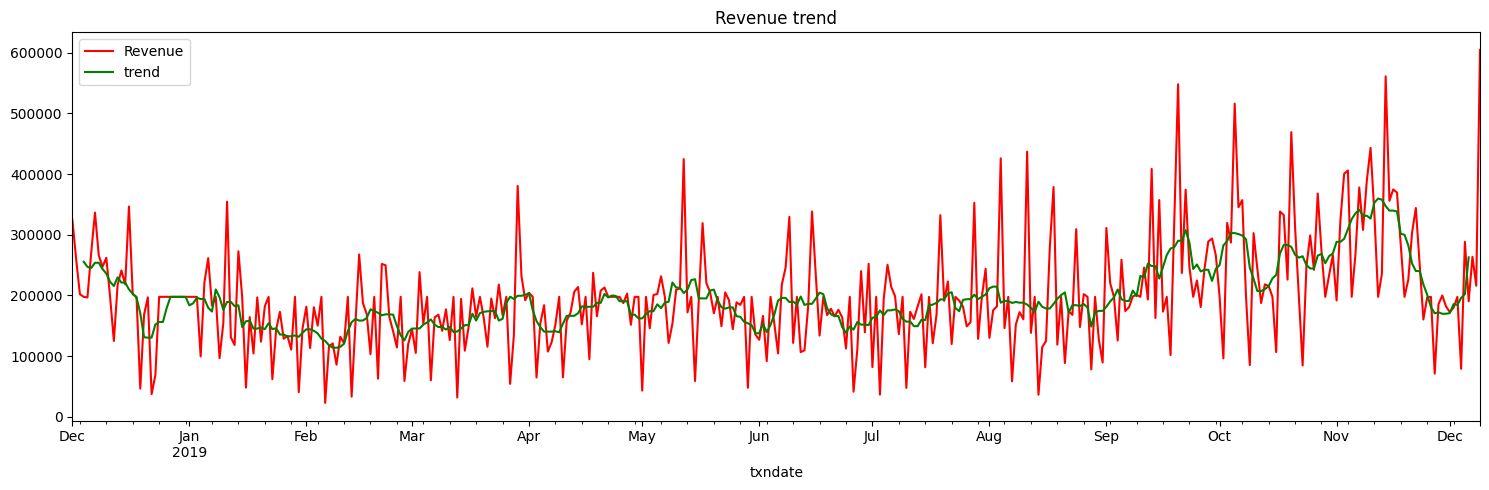

In [126]:
plt.figure(figsize = (15,5))
add_result.observed.plot(color='r')
add_result.trend.plot(color='g')
plt.title('Revenue trend')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


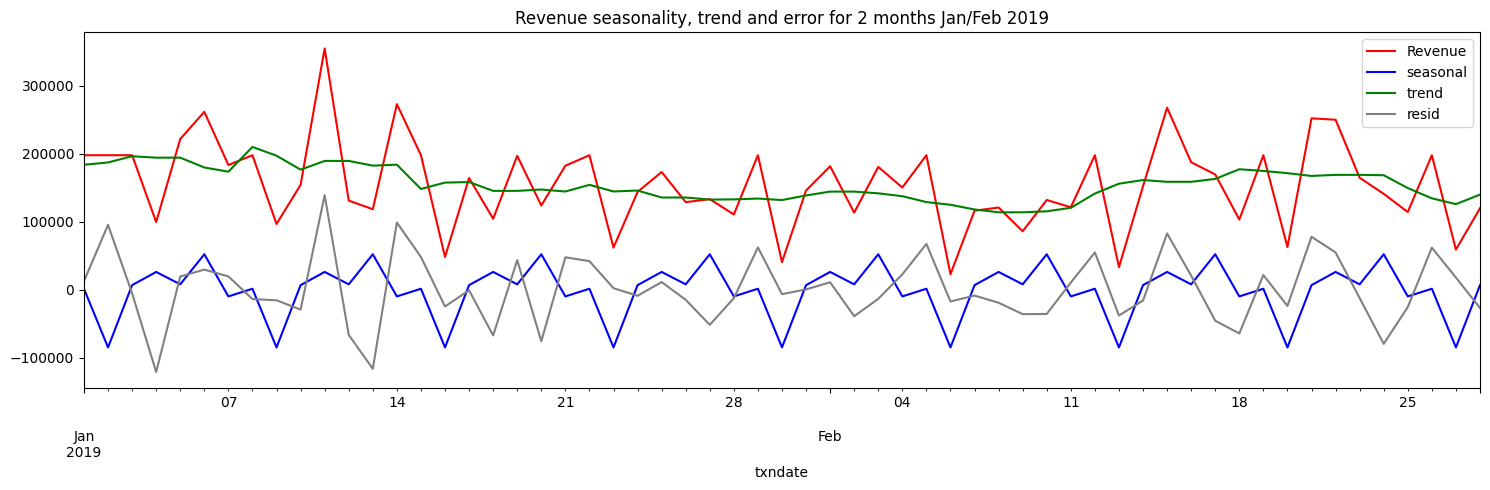

In [127]:
plt.figure(figsize = (15,5))
add_result.observed['2019-01':'2019-02'].plot(color='r')
add_result.seasonal['2019-01':'2019-02'].plot(color='b')
add_result.trend['2019-01':'2019-02'].plot(color='g')
add_result.resid['2019-01':'2019-02'].plot(color='gray')
plt.title('Revenue seasonality, trend and error for 2 months Jan/Feb 2019')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


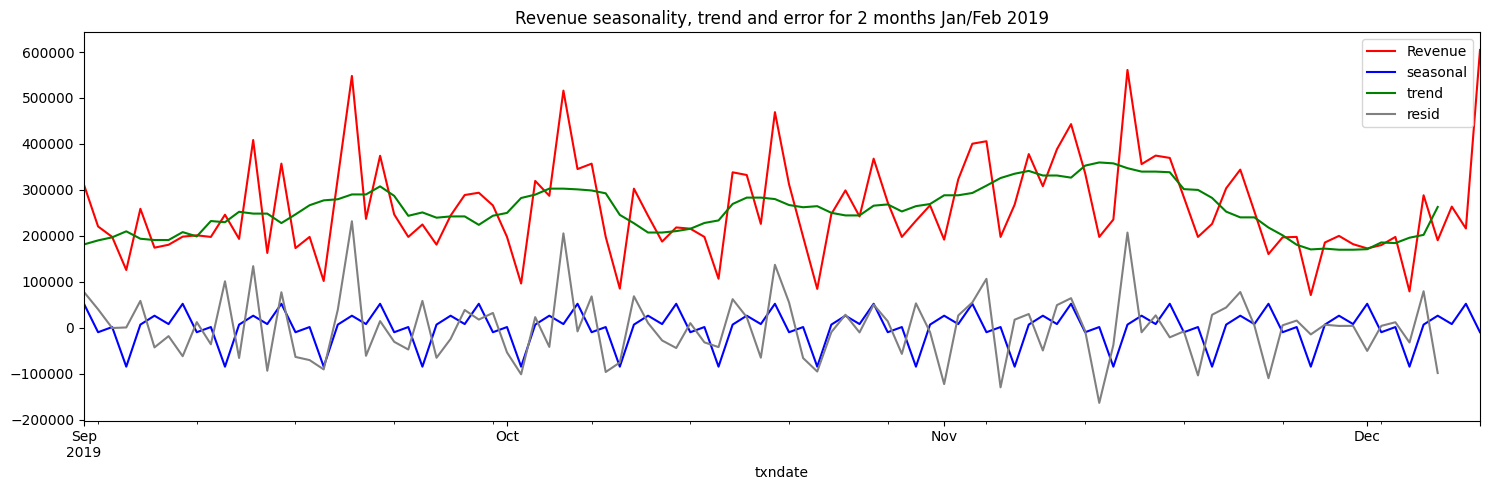

In [128]:
plt.figure(figsize = (15,5))
add_result.observed['2019-09':'2019-12'].plot(color='r')
add_result.seasonal['2019-09':'2019-12'].plot(color='b')
add_result.trend['2019-09':'2019-12'].plot(color='g')
add_result.resid['2019-09':'2019-12'].plot(color='gray')
plt.title('Revenue seasonality, trend and error for 2 months Jan/Feb 2019')
plt.legend()
plt.tight_layout()
plt.show()

In [129]:
revts

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Revenue
txndate,
2018-12-01,324649.230000
2018-12-02,260301.650000
2018-12-03,201975.180000
2018-12-04,197639.423803
2018-12-05,196630.800000
...,...
2019-12-05,288295.470000
2019-12-06,190335.340000
2019-12-07,263611.260000


<hr>

## Answer 2.2
<hr>

In [130]:
revts_sample = revts['2019-01-01':'2019-11-01']

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [131]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [132]:
# Reference : https://www.kaggle.com/code/iamleonie/time-series-interpreting-acf-and-pacf

from statsmodels.tsa.stattools import adfuller
def check_stationarity(series):
    # Copied from https://machinelearningmastery.com/time-series-data-stationary-python/

    result = adfuller(series.values)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    #print('Critical Values:')
    #for key, value in result[4].items():
    #    print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [133]:
print('Original')
check_stationarity(revts_sample.Revenue)
print('--------------------------------')
print('1st Differencing')
check_stationarity(revts_sample.Revenue.diff().dropna())
print('--------------------------------')
print('2nd Differencing')
print(check_stationarity(revts_sample.Revenue.diff().diff().dropna()))

Original
ADF Statistic: -1.191542
p-value: 0.677224
Non-stationary
--------------------------------
1st Differencing
ADF Statistic: -8.884668
p-value: 0.000000
Stationary
--------------------------------
2nd Differencing
ADF Statistic: -9.786818
p-value: 0.000000
Stationary
None


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


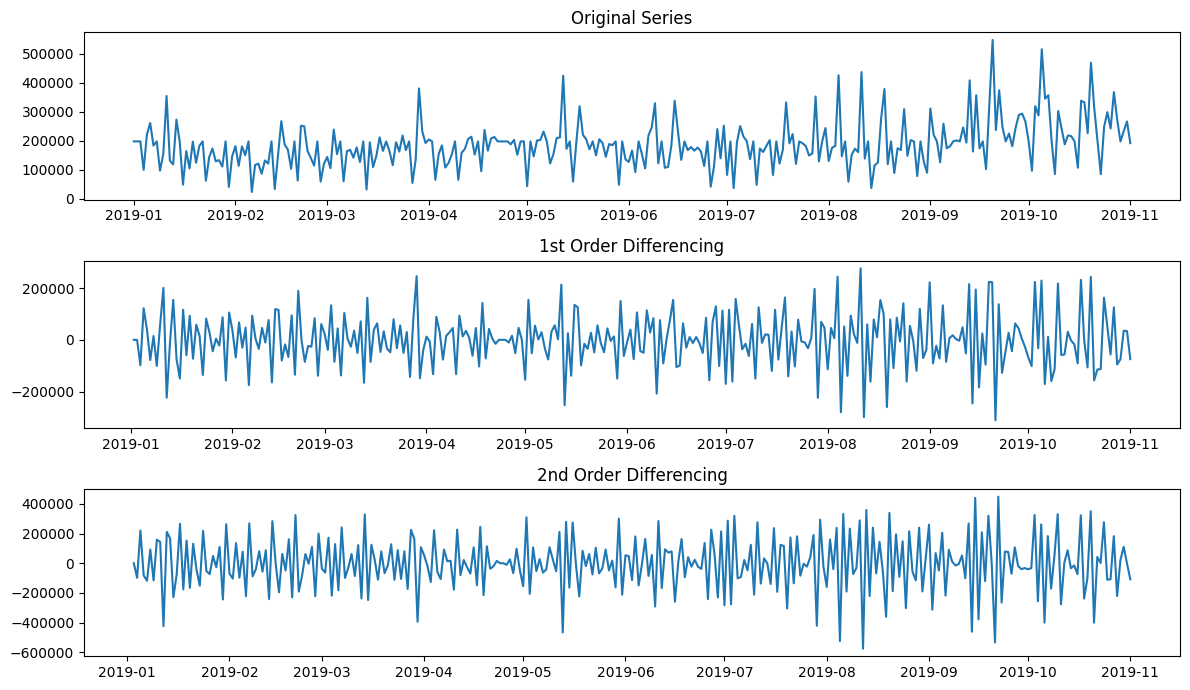

In [134]:
f1, a1 = plt.subplots(3,1, figsize=(12,7))
# Original Series
a1[0].plot(revts_sample.Revenue)
a1[0].set_title('Original Series')
# 1st Differencing
a1[1].plot(revts_sample.Revenue.diff().dropna())
a1[1].set_title('1st Order Differencing')
# 2nd Differencing
a1[2].plot(revts_sample.Revenue.diff().diff().dropna())
a1[2].set_title('2nd Order Differencing')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


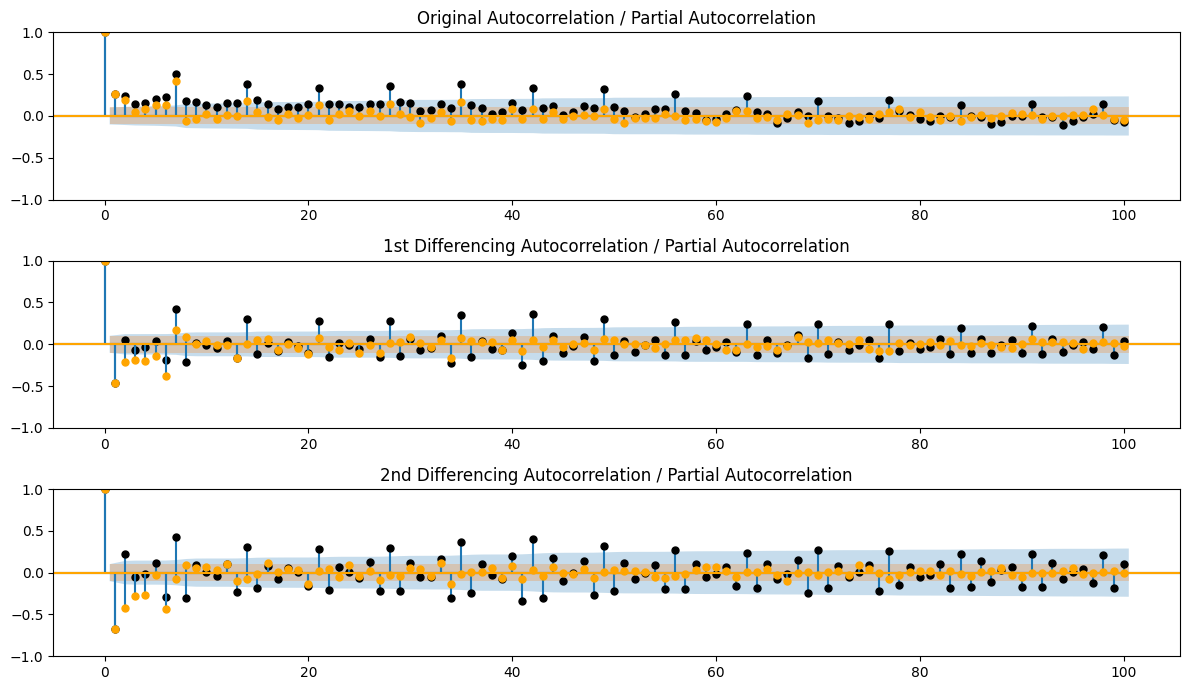

In [135]:
# Original Series
f2, a2 = plt.subplots(3,1, figsize=(12,7))
plot_acf(revts.Revenue, ax=a2[0], color='black', lags=100)
plot_pacf(revts.Revenue, ax=a2[0], method='ywm', color='orange', lags=100)
a2[0].set_title('Original Autocorrelation / Partial Autocorrelation')

# 1st Differencing
plot_acf(revts.Revenue.diff().dropna(), ax=a2[1], color='black', lags=100)
plot_pacf(revts.Revenue.diff().dropna(), ax=a2[1], method='ywm', color='orange', lags=100)
a2[1].set_title('1st Differencing Autocorrelation / Partial Autocorrelation')

# 2nd Differencing
plot_acf(revts.Revenue.diff().diff().dropna(), ax=a2[2], color='black', lags=100)
plot_pacf(revts.Revenue.diff().diff().dropna(), ax=a2[2], method='ywm', color='orange', lags=100)
a2[2].set_title('2nd Differencing Autocorrelation / Partial Autocorrelation')

plt.tight_layout()
plt.show()

In [136]:
# evaluate an ARIMA model using a walk-forward validation
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# split into train and test sets
X = revts_sample.Revenue.values
X = X.astype('float32')
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:]
history = [x for x in train]
predictions = list()
RMSE = []
MAE = []
p=[0,1,2]
q=[0,1,2]
d=[0,1,2]
params = []
# walk-forward validation
for i1 in p:
  for i2 in q:
    for i3 in d:
      model = ARIMA(history, order=(i1,i3,i2))
      model_fit = model.fit()
      result = model_fit.forecast()
      for t in range(len(test)):
        yhat = result[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
      rmse = sqrt(mean_squared_error(test, predictions))
      mae = mean_absolute_error(test,predictions)
      RMSE.append(float(rmse))
      MAE.append(float(mae))
      parstr = "p=" + str(i1) + ", d=" + str(i3) + ", q=" + str(i2)
      params.append(parstr)
      # Reset the lists
      history = [x for x in train]
      predictions = list()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [137]:
grid_s_results = pd.DataFrame(np.column_stack([params, RMSE, MAE]),
              columns=['Parameters', 'RMSE', 'MAE'])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [138]:
grid_s_results['RMSE']=grid_s_results['RMSE'].astype('float')
grid_s_results['MAE']=grid_s_results['MAE'].astype('float')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [139]:
grid_s_results.sort_values(['MAE'])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Parameters,RMSE,MAE
24,"p=2, d=0, q=2",101162.962882,71691.763228
5,"p=0, d=2, q=1",101906.910876,72296.309560
1,"p=0, d=1, q=0",102181.722757,72537.545823
8,"p=0, d=2, q=2",106610.477943,76351.384739
19,"p=2, d=1, q=0",97798.975659,77790.700596
23,"p=2, d=2, q=1",97913.150570,78019.037094
4,"p=0, d=1, q=1",109050.833911,78569.002642
13,"p=1, d=1, q=1",109432.849025,78949.958523
17,"p=1, d=2, q=2",109496.910067,79013.709923
7,"p=0, d=1, q=2",109640.630207,79161.911008


In [140]:
from statsmodels.tsa.arima.model import ARIMA

# split into train and test sets
X = revts_sample.Revenue.values
X = X.astype('float32')
size = len(X) - 1
train, test = X[0:size], X[size:]

# fit an ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()
# forecast
result = model_fit.get_forecast()

# summarize forecast and confidence intervals
print('Expected: %.3f' % result.predicted_mean)
print('Forecast: %.3f' % test[0])
print('Standard Error: %.3f' % result.se_mean)
ci = result.conf_int(0.05)
print('95%% Interval: %.3f to %.3f' % (ci[0,0], ci[0,1]))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Expected: 194062.016
Forecast: 191721.312
Standard Error: 79852.089
95% Interval: 37554.797 to 350569.234


<ipython-input-140-d918132821c1>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Expected: %.3f' % result.predicted_mean)
<ipython-input-140-d918132821c1>:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Standard Error: %.3f' % result.se_mean)


<hr>

## Answer 2.3
<hr>